In [1]:
# Student Performance Prediction Using Machine Learning
# Part 1: Creating and Loading the Student Dataset

import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic student data
n_students = 500

study_hours = np.random.uniform(0, 10, n_students).round(1)
attendance = np.random.uniform(50, 100, n_students).round(1)
previous_score = np.random.uniform(30, 100, n_students).round(1)
sleep_hours = np.random.uniform(4, 10, n_students).round(1)
extracurricular = np.random.choice(["Yes", "No"], n_students)
internet_access = np.random.choice(["Yes", "No"], n_students, p=[0.8, 0.2])

# Final score depends on the student habits plus some random noise
final_score = (
    3.5 * study_hours
    + 0.3 * attendance
    + 0.35 * previous_score
    + 1.5 * np.minimum(sleep_hours - 7, 0)
    + np.where(internet_access == "Yes", 3, 0)
    + np.random.normal(0, 6, n_students)
    - 15
).clip(0, 100).round(1)

data = pd.DataFrame({
    "Student_ID": range(1, n_students + 1),
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Previous_Score": previous_score,
    "Sleep_Hours": sleep_hours,
    "Extracurricular": extracurricular,
    "Internet_Access": internet_access,
    "Final_Score": final_score
})

# Display the first five rows
data.head()

,Student_ID,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Extracurricular,Internet_Access,Final_Score
0,1,3.7,84.9,43.0,7.1,No,Yes,51.0
1,2,9.5,76.8,67.9,6.9,Yes,No,58.8
2,3,7.3,65.5,91.1,4.2,Yes,Yes,56.0
3,4,6.0,90.7,81.3,6.0,Yes,No,52.6
4,5,1.6,84.2,86.5,6.3,No,No,43.7


### Key Observation

The dataset contains information about 500 students, including their daily study hours, attendance percentage, previous exam score, sleep hours, extracurricular participation, and internet access.

The final exam score is the main outcome of interest. These features will be used to predict whether a student is likely to pass or fail.

In [2]:
# Part 2: Dataset Inspection and Validation

# Display the dataset shape
print("Dataset Shape:", data.shape)

# Display information about the dataset
print("\nDataset Information:")
data.info()

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Check for duplicate student records
print("\nDuplicate Rows:", data.duplicated().sum())

Dataset Shape: (500, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       500 non-null    int64  
 1   Study_Hours      500 non-null    float64
 2   Attendance       500 non-null    float64
 3   Previous_Score   500 non-null    float64
 4   Sleep_Hours      500 non-null    float64
 5   Extracurricular  500 non-null    object 
 6   Internet_Access  500 non-null    object 
 7   Final_Score      500 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 31.4+ KB

Missing Values:
Student_ID         0
Study_Hours        0
Attendance         0
Previous_Score     0
Sleep_Hours        0
Extracurricular    0
Internet_Access    0
Final_Score        0
dtype: int64

Duplicate Rows: 0


### Key Observation

The dataset contains no missing values or duplicate records, so no data cleaning is required before the analysis.

Most features are numerical, while extracurricular participation and internet access are categorical variables that will need to be encoded before training the machine learning models.

In [3]:
# Part 3: Summary Statistics

# Display summary statistics for numerical features
display(data.describe().round(2))

# Count values for categorical features
print("Extracurricular Participation:")
print(data["Extracurricular"].value_counts())

print("\nInternet Access:")
print(data["Internet_Access"].value_counts())

,Student_ID,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,250.50,4.99,74.10,66.23,6.98,49.36
std,144.48,2.99,14.27,20.80,1.72,14.95
min,1.00,0.10,50.20,30.30,4.00,5.30
25%,125.75,2.40,61.48,46.85,5.40,39.10
50%,250.50,5.10,73.60,67.80,7.10,49.70
75%,375.25,7.60,86.32,84.45,8.40,59.75
max,500.00,9.90,100.00,100.00,10.00,90.40


Extracurricular Participation:
Extracurricular
No     258
Yes    242
Name: count, dtype: int64

Internet Access:
Internet_Access
Yes    409
No      91
Name: count, dtype: int64


### Key Observation

The summary statistics show the range and average of each student characteristic.

Study hours range from 0 to 10 hours per day, while attendance ranges from 50% to 100%. Most students have internet access, and extracurricular participation is fairly evenly split between students.

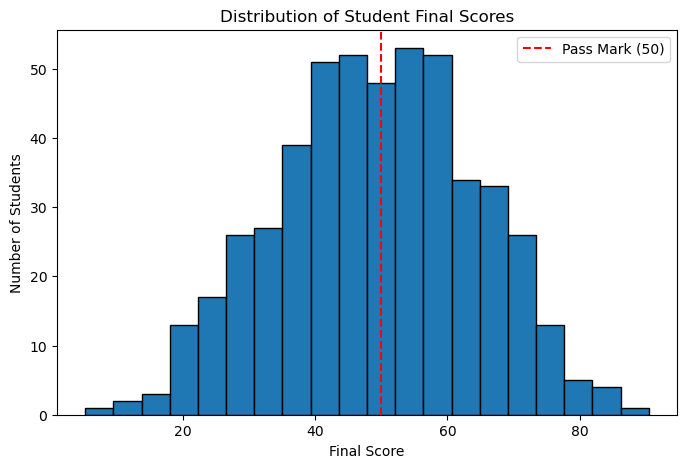

In [4]:
# Part 4: Visualising the Final Score Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    data["Final_Score"],
    bins=20,
    edgecolor="black"
)

# Mark the pass mark on the chart
plt.axvline(
    50,
    color="red",
    linestyle="--",
    label="Pass Mark (50)"
)

plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Final Scores")
plt.legend()

plt.show()

### Key Observation

The histogram shows how final scores are spread across the student population.

The red dashed line marks the pass mark of 50. Students to the left of this line failed the exam, while students to the right passed. This will be used to create the target variable for classification.